# Bilişsel Performans Skoru — Keşifsel Veri Analizi

**Yarışma:** YZTA 2026 Datathon — Grup 27
**Sorumlu:** Sezin
**Tarih:** 10 Mayıs 2026

## İçerik

1. Kütüphaneler ve veri yükleme
2. Veri büyüklüğü, dtype, eksik değerler
3. Target dağılımı
4. Sayısal feature dağılımları
5. Kategorik feature analizi
6. Korelasyon analizi
7. Eksik değer pattern'i
8. Train vs Test karşılaştırması
9. Outlier tespiti
10. Bulgular özeti

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

SEED = 42
np.random.seed(SEED)

print("Kütüphaneler yüklendi ✓")


Kütüphaneler yüklendi ✓


In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test_x.csv')
sample = pd.read_csv('../data/sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Sample shape: {sample.shape}")

Train shape: (56000, 24)
Test shape:  (24000, 23)
Sample shape: (2, 2)


In [3]:
train.head()

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  str    
 3   meslek                       54622 non-null  str    
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  str    
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi_dk        

In [5]:
train.describe()

,id,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,bilissel_performans_skoru
count,56000.000000,56000.000000,54248.000000,56000.000000,56000.000000,56000.000000,56000.000000,54537.000000,56000.000000,56000.000000,56000.000000,54285.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,28000.500000,34.714446,26.273651,20.233500,20.246063,20.107536,3.344929,42.110952,63.511446,7493.197554,15.432875,5.741407,7.156456,66.603214,20.531263,1.199050,5.913096
std,16165.951874,11.052508,4.495138,3.442993,4.300421,8.063278,2.034618,72.154159,44.590737,3462.699361,21.104672,1.624985,3.469731,7.353174,2.903317,0.790899,2.231759
min,1.000000,18.000000,16.000000,10.000000,5.000000,1.000000,0.000000,0.000000,2.000000,500.000000,0.000000,1.000000,0.000000,45.000000,15.000000,-1.000000,0.000000
25%,14000.750000,26.000000,23.175279,17.951724,17.337866,14.000000,2.000000,0.000000,30.000000,5042.000000,0.000000,4.761271,4.765942,62.000000,18.457240,0.660030,4.397431
50%,28000.500000,33.000000,26.225806,20.302218,20.292151,20.000000,3.000000,3.000000,51.000000,7426.000000,2.000000,5.824014,7.360860,67.000000,20.487456,1.202921,6.032249
75%,42000.250000,42.000000,29.321503,22.598180,23.227117,25.000000,5.000000,77.000000,84.000000,9876.000000,30.000000,6.837436,9.684531,72.000000,22.522152,1.743940,7.574980
max,56000.000000,69.000000,45.000000,30.000000,30.000000,58.000000,8.000000,400.000000,180.000000,20000.000000,115.000000,10.000000,18.000000,97.000000,28.000000,3.000000,10.000000


In [6]:
train.describe(include='object')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1040\1464152888.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include='object')


,cinsiyet,meslek,ulke,kronotip,ruh_sagligi_durumu,mevsim,gun_tipi
count,56000,54622,56000,54032,54904,56000,56000
unique,2,11,15,3,4,2,2
top,Kadin,Saglik Personeli,Ingiltere,Notr,Saglikli,Ilkbahar-Yaz,Hafta ici
freq,28676,9842,11324,24594,38365,28143,40052


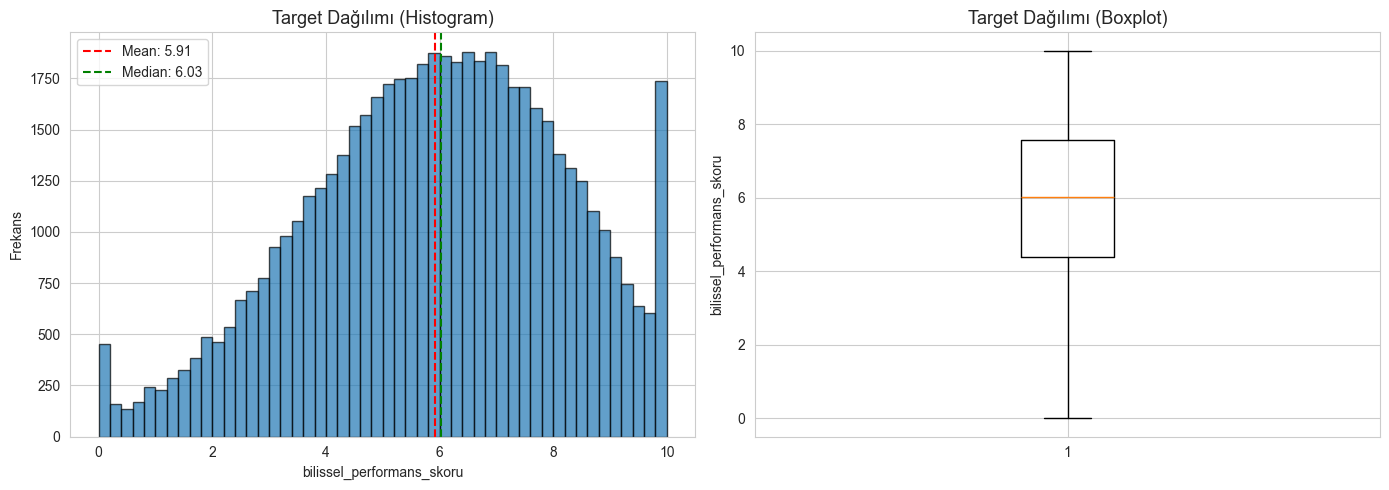

In [7]:
# Target dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train['bilissel_performans_skoru'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Target Dağılımı (Histogram)', fontsize=13)
axes[0].set_xlabel('bilissel_performans_skoru')
axes[0].set_ylabel('Frekans')
axes[0].axvline(train['bilissel_performans_skoru'].mean(), color='red', linestyle='--', label=f"Mean: {train['bilissel_performans_skoru'].mean():.2f}")
axes[0].axvline(train['bilissel_performans_skoru'].median(), color='green', linestyle='--', label=f"Median: {train['bilissel_performans_skoru'].median():.2f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(train['bilissel_performans_skoru'], vert=True)
axes[1].set_title('Target Dağılımı (Boxplot)', fontsize=13)
axes[1].set_ylabel('bilissel_performans_skoru')

plt.tight_layout()
plt.show()

### Target Bulguları

- **Dağılım simetrik:** Mean (5.91) ≈ Median (6.03), log transform gerekmiyor
- **Range:** 0–10 arası sürekli skor
- **Pile-up gözlendi:** Hem 0'da (~450 satır) hem 10'da (~1750 satır) belirgin yığılma var → **clipping/ceiling etkisi**
- **Outlier yok:** Boxplot kutunun dışında değer yok, sınırlar doğal
- **Modelleme notu:** 10'daki ceiling, regresyon modellerinde bias yaratabilir

C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


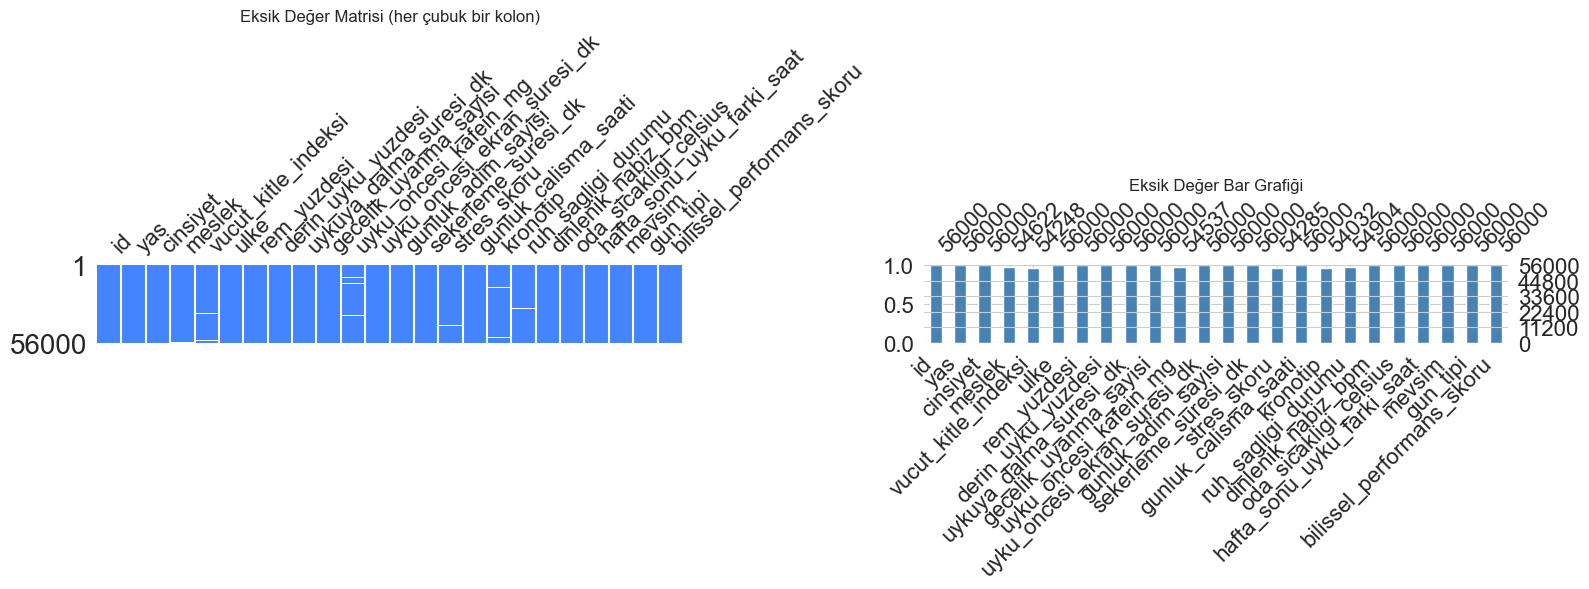

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

msno.matrix(train, ax=axes[0], color=(0.27, 0.52, 1.0))
axes[0].set_title('Eksik Değer Matrisi (her çubuk bir kolon)', fontsize=12)

msno.bar(train, ax=axes[1], color='steelblue')
axes[1].set_title('Eksik Değer Bar Grafiği', fontsize=12)

plt.tight_layout()
plt.show()

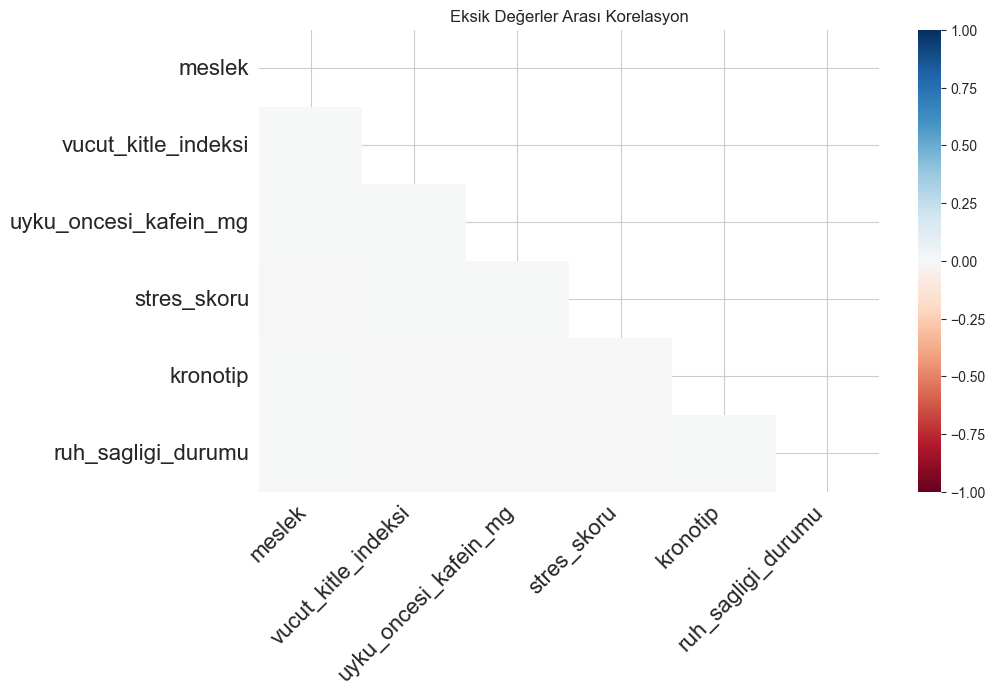

In [9]:
msno.heatmap(train, figsize=(10, 6))
plt.title('Eksik Değerler Arası Korelasyon')
plt.show()

In [10]:
missing = pd.DataFrame({
    'Eksik Sayı': train.isnull().sum(),
    'Eksik %': (train.isnull().sum() / len(train) * 100).round(2),
    'Dtype': train.dtypes
})
missing = missing[missing['Eksik Sayı'] > 0].sort_values('Eksik Sayı', ascending=False)
print("Eksik değer içeren kolonlar:\n")
print(missing)

Eksik değer içeren kolonlar:

                       Eksik Sayı  Eksik %    Dtype
kronotip                     1968     3.51      str
vucut_kitle_indeksi          1752     3.13  float64
stres_skoru                  1715     3.06  float64
uyku_oncesi_kafein_mg        1463     2.61  float64
meslek                       1378     2.46      str
ruh_sagligi_durumu           1096     1.96      str


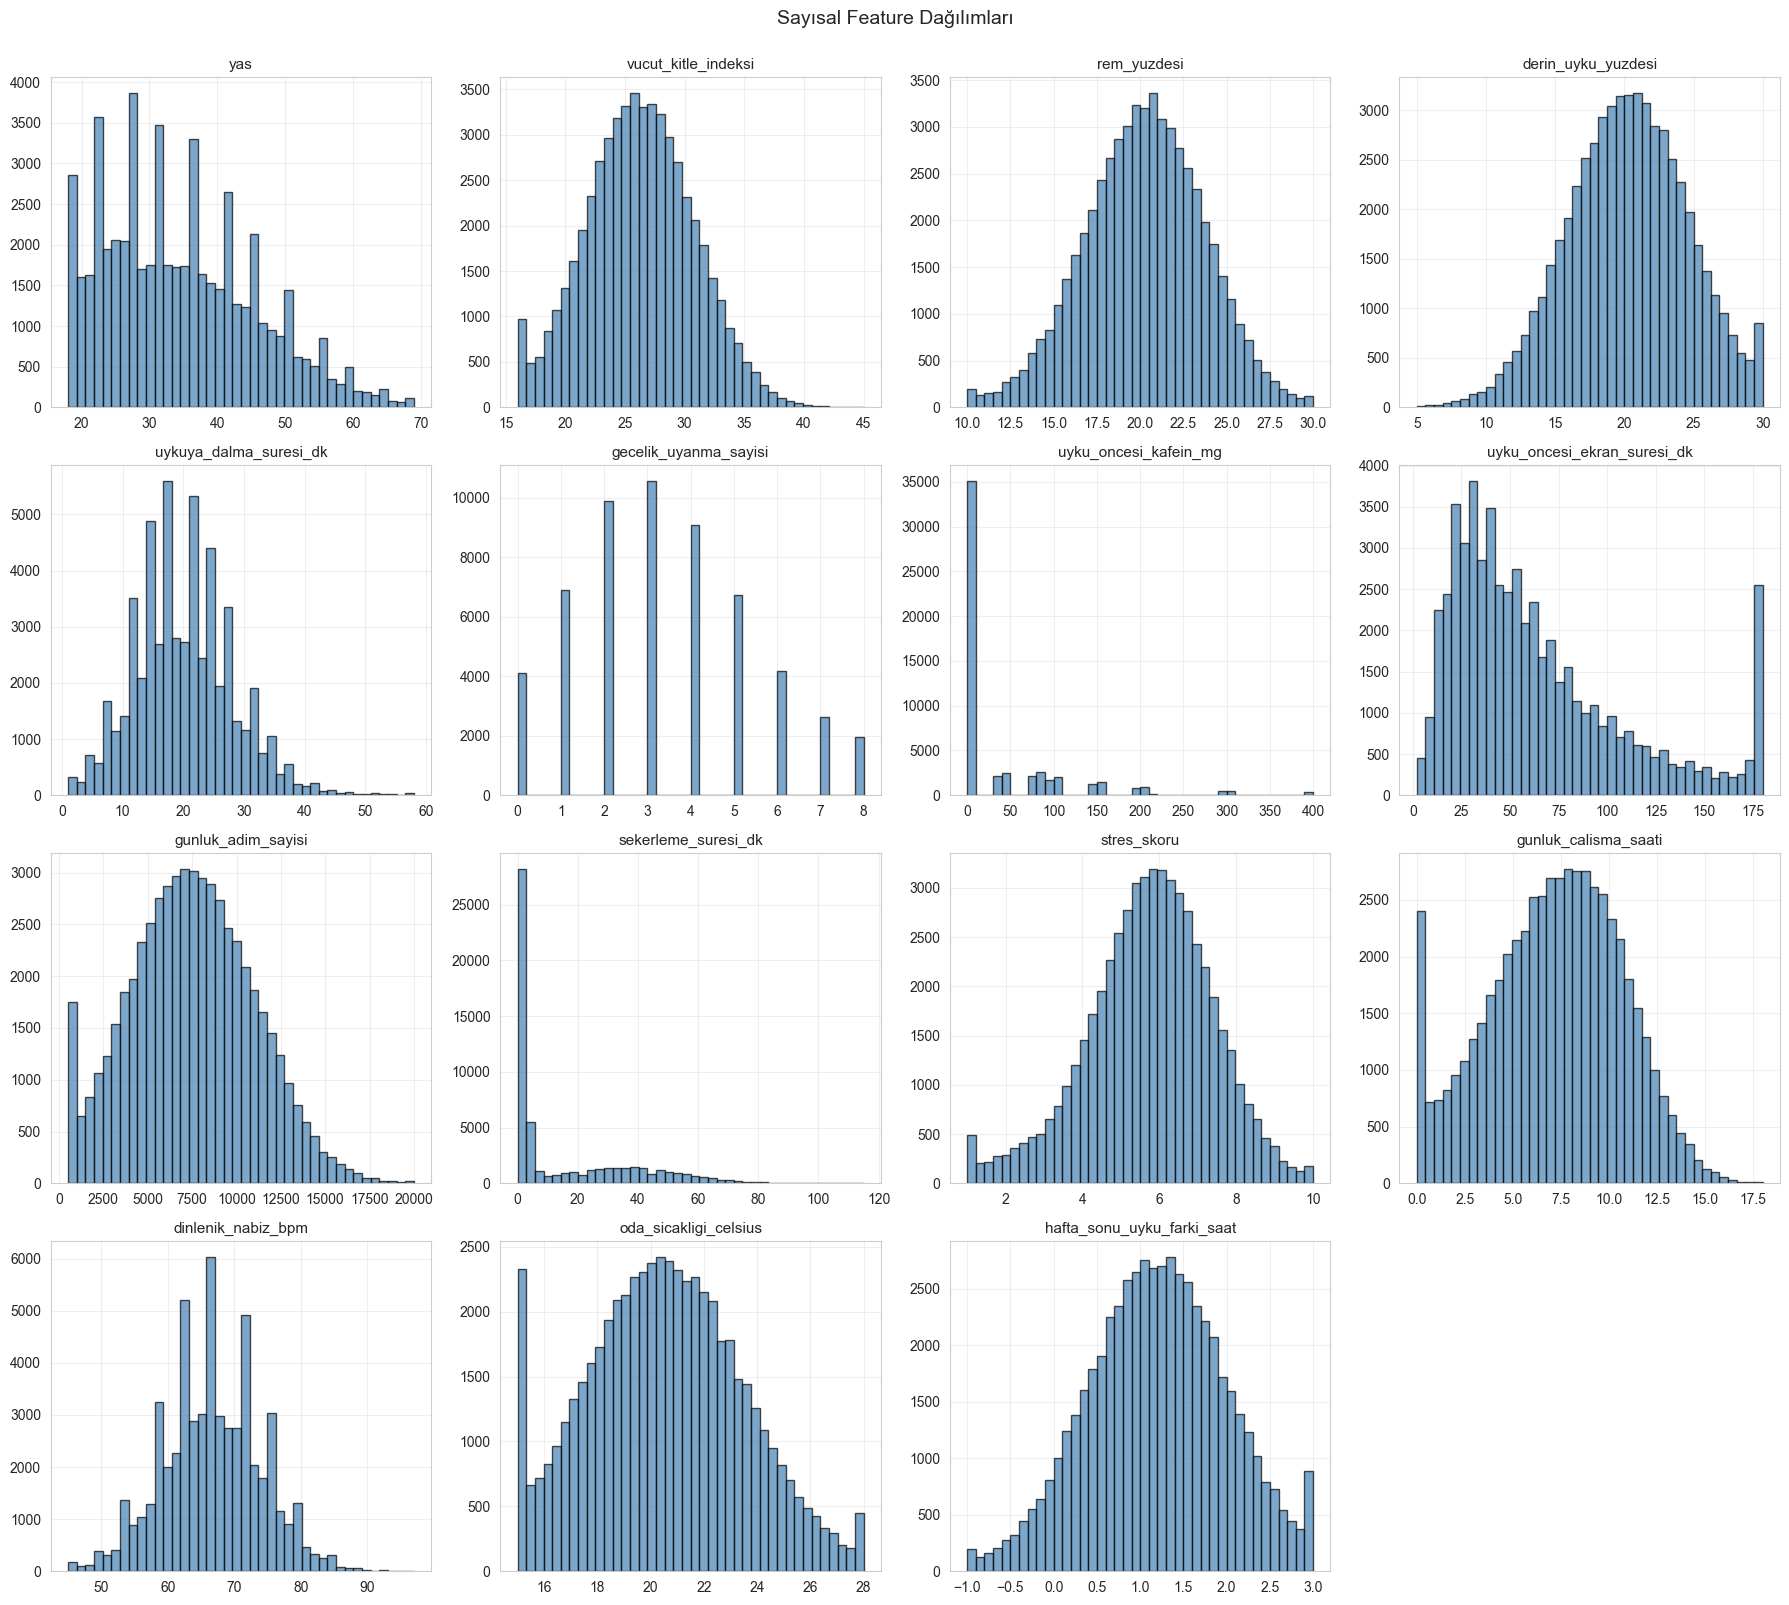


Toplam sayısal feature: 15
Kolonlar: ['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat']


In [11]:
# Sayısal feature dağılımları
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('id')  # id feature değil
numeric_cols.remove('bilissel_performans_skoru')  # target ayrı analiz edildi

# Subplot grid
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(train[col].dropna(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].grid(alpha=0.3)

# Boş kalan subplot'ları gizle
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sayısal Feature Dağılımları', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print(f"\nToplam sayısal feature: {len(numeric_cols)}")
print("Kolonlar:", numeric_cols)

### Sayısal Feature Bulguları

- **`uyku_oncesi_kafein_mg`:** Veri setinin ~%57'si 0 mg (kafein almıyor). Binary feature olarak değerlendirilebilir.
- **`sekerleme_suresi_dk`:** Veri setinin ~%50'si 0 dk (şekerleme yapmıyor). Aynı şekilde binary feature potansiyeli.
- **`yas`:** Sağa çarpık dağılım, 18-40 yoğunluklu.
- **`dinlenik_nabiz_bpm`:** Tam sayılarda yığılma var (ölçüm hassasiyeti).
- **`gecelik_uyanma_sayisi`:** Discrete (0-8), kategorik gibi davranıyor.
- **Çan eğrisi:** vucut_kitle_indeksi, rem/derin_uyku_yuzdesi, gunluk_adim_sayisi, stres_skoru, oda_sicakligi_celsius, hafta_sonu_uyku_farki_saat.

**Modelleme notu:** Tree-based modeller (LightGBM, XGBoost) bu dağılımlardan etkilenmez. Skewed feature'lar için log transform gerekmez.

In [12]:
# Kategorik feature'lar
categorical_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()
# Eğer 'str' dtype varsa onları da yakala
str_cols = [c for c in train.columns if train[c].dtype.name == 'string' or train[c].dtype.name == 'object']
categorical_cols = list(set(categorical_cols + str_cols))

print(f"Toplam kategorik feature: {len(categorical_cols)}")
print("Kolonlar:", categorical_cols)

# Her birinin unique sayısı
print("\nUnique değer sayıları:")
for col in categorical_cols:
    print(f"  {col}: {train[col].nunique()} unique")

Toplam kategorik feature: 7
Kolonlar: ['kronotip', 'mevsim', 'gun_tipi', 'ulke', 'cinsiyet', 'ruh_sagligi_durumu', 'meslek']

Unique değer sayıları:
  kronotip: 3 unique
  mevsim: 2 unique
  gun_tipi: 2 unique
  ulke: 15 unique
  cinsiyet: 2 unique
  ruh_sagligi_durumu: 4 unique
  meslek: 11 unique


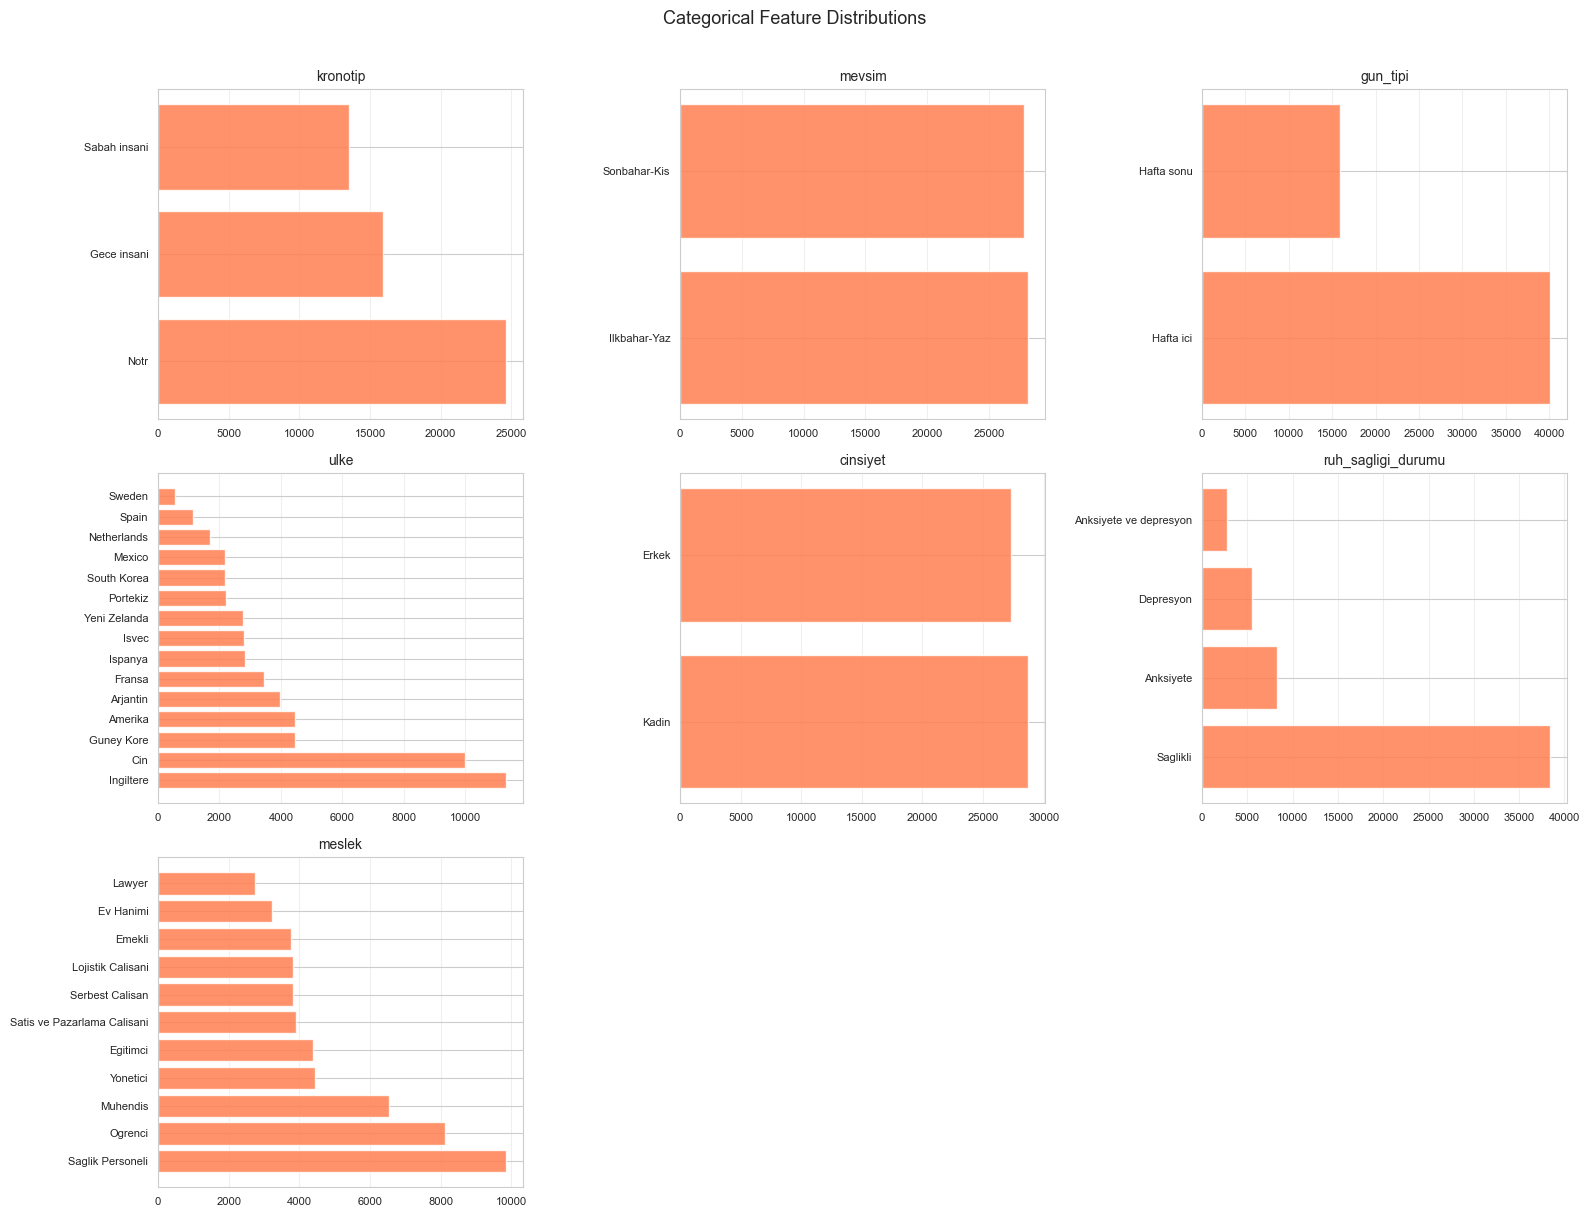

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    vc = train[col].value_counts()
    axes[i].barh(vc.index.astype(str), vc.values, color='coral', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].tick_params(labelsize=8)
    axes[i].grid(axis='x', alpha=0.3)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Categorical Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Kategorik Feature Bulguları

- **ulke**: 15 ülke, İngiltere baskın (~10K). Dağılım dengesiz → target encoding uygun (Buse).
- **cinsiyet**: 2 sınıf, Erkek/Kadın dengeli (~28K / ~28K).
- **kronotip**: 3 sınıf — Gece insanı en yoğun (~24K), Sabah insanı en az. Uyku kalitesiyle ilişkili olabilir.
- **ruh_sagligi_durumu**: 4 sınıf — Sağlıklı baskın (~38K), Anksiyete ve Depresyon düşük. Class imbalance var.
- **gun_tipi**: 2 sınıf, Hafta içi biraz daha yoğun (~40K vs ~16K).
- **meslek**: 11 sınıf, Sağlık Personeli en fazla (~9.5K), Lawyer en az. Yüksek kardinalite → target encoding (Buse).
- **mevsim**: 2 sınıf, İlkbahar-Yaz / Sonbahar-Kış dengeli.

**Modelleme notu:** `ulke` ve `meslek` yüksek kardinaliteli → LabelEncoder yerine target encoding tercih edilmeli (Buse pipeline).

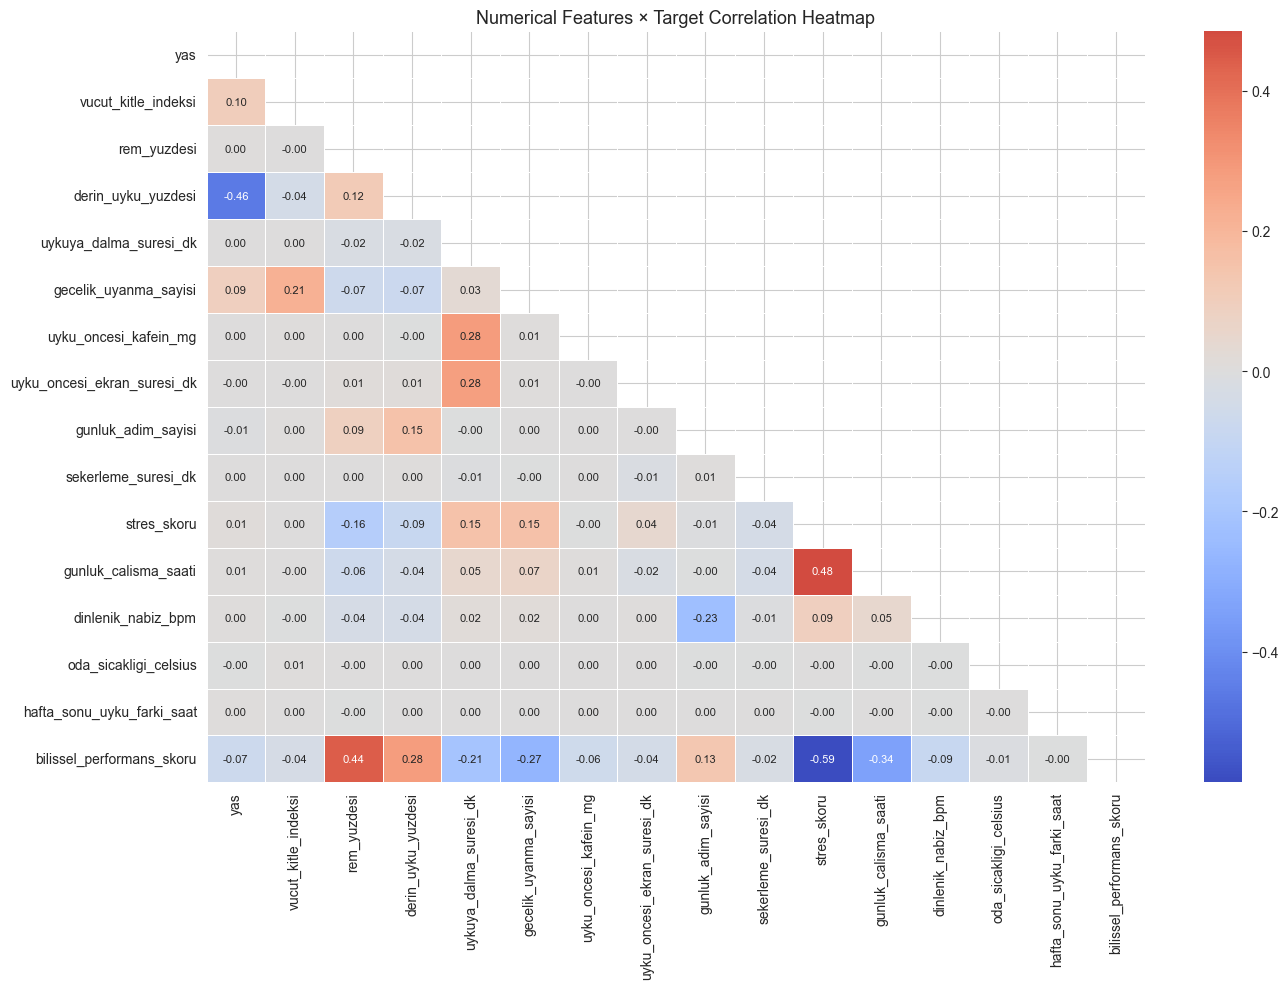

Target ile korelasyon (mutlak değer sıralaması):
stres_skoru                   -0.587
rem_yuzdesi                    0.443
gunluk_calisma_saati          -0.342
derin_uyku_yuzdesi             0.280
gecelik_uyanma_sayisi         -0.270
uykuya_dalma_suresi_dk        -0.207
gunluk_adim_sayisi             0.134
dinlenik_nabiz_bpm            -0.089
yas                           -0.071
uyku_oncesi_kafein_mg         -0.062
uyku_oncesi_ekran_suresi_dk   -0.045
vucut_kitle_indeksi           -0.038
sekerleme_suresi_dk           -0.024
oda_sicakligi_celsius         -0.012
hafta_sonu_uyku_farki_saat    -0.002
Name: bilissel_performans_skoru, dtype: float64


In [14]:
corr_cols = [c for c in numeric_cols if train[c].notna().sum() > 0]

corr_matrix = train[corr_cols + ['bilissel_performans_skoru']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Numerical Features × Target Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

# Target ile en yüksek korelasyonlar
target_corr = corr_matrix['bilissel_performans_skoru'].drop('bilissel_performans_skoru').sort_values(key=abs, ascending=False)
print("Target ile korelasyon (mutlak değer sıralaması):")
print(target_corr.round(3))

## Korelasyon Bulguları

### Target ile En Güçlü İlişkiler
| Feature | Korelasyon | Yön |
|---|---|---|
| stres_skoru | -0.59 | Stres arttıkça performans düşüyor |
| rem_yuzdesi | +0.44 | REM uykusu arttıkça performans artıyor |
| gunluk_calisma_saati | -0.34 | Fazla çalışma performansı düşürüyor |
| derin_uyku_yuzdesi | +0.28 | Derin uyku performansı artırıyor |
| gecelik_uyanma_sayisi | -0.27 | Gece uyanmaları performansı düşürüyor |
| uykuya_dalma_suresi_dk | -0.21 | Geç uykuya dalmak performansı düşürüyor |

### Feature Engineering İçin Çıkarımlar
- `stres_skoru × gunluk_calisma_saati` → `add_stress_workload` güçlü olabilir (-0.59, -0.34)
- `rem_yuzdesi + derin_uyku_yuzdesi` → `add_sleep_efficiency` anlamlı (+0.44, +0.28)
- `gecelik_uyanma_sayisi + uykuya_dalma_suresi_dk` → uyku kalitesini birlikte yakalıyor

### Feature'lar Arası Dikkat Çeken İlişki
- `gunluk_calisma_saati × dinlenik_nabiz_bpm`: +0.45 → fazla çalışanların nabzı yüksek (stres marker)
- `derin_uyku_yuzdesi × rem_yuzdesi`: -0.46 → ters orantılı, biri artarken diğeri azalıyor (toplam %100'e yakın)

### Zayıf Feature'lar (modelde düşük öncelik)
- `oda_sicakligi_celsius` (-0.01), `hafta_sonu_uyku_farki_saat` (-0.00), `sekerleme_suresi_dk` (-0.02)

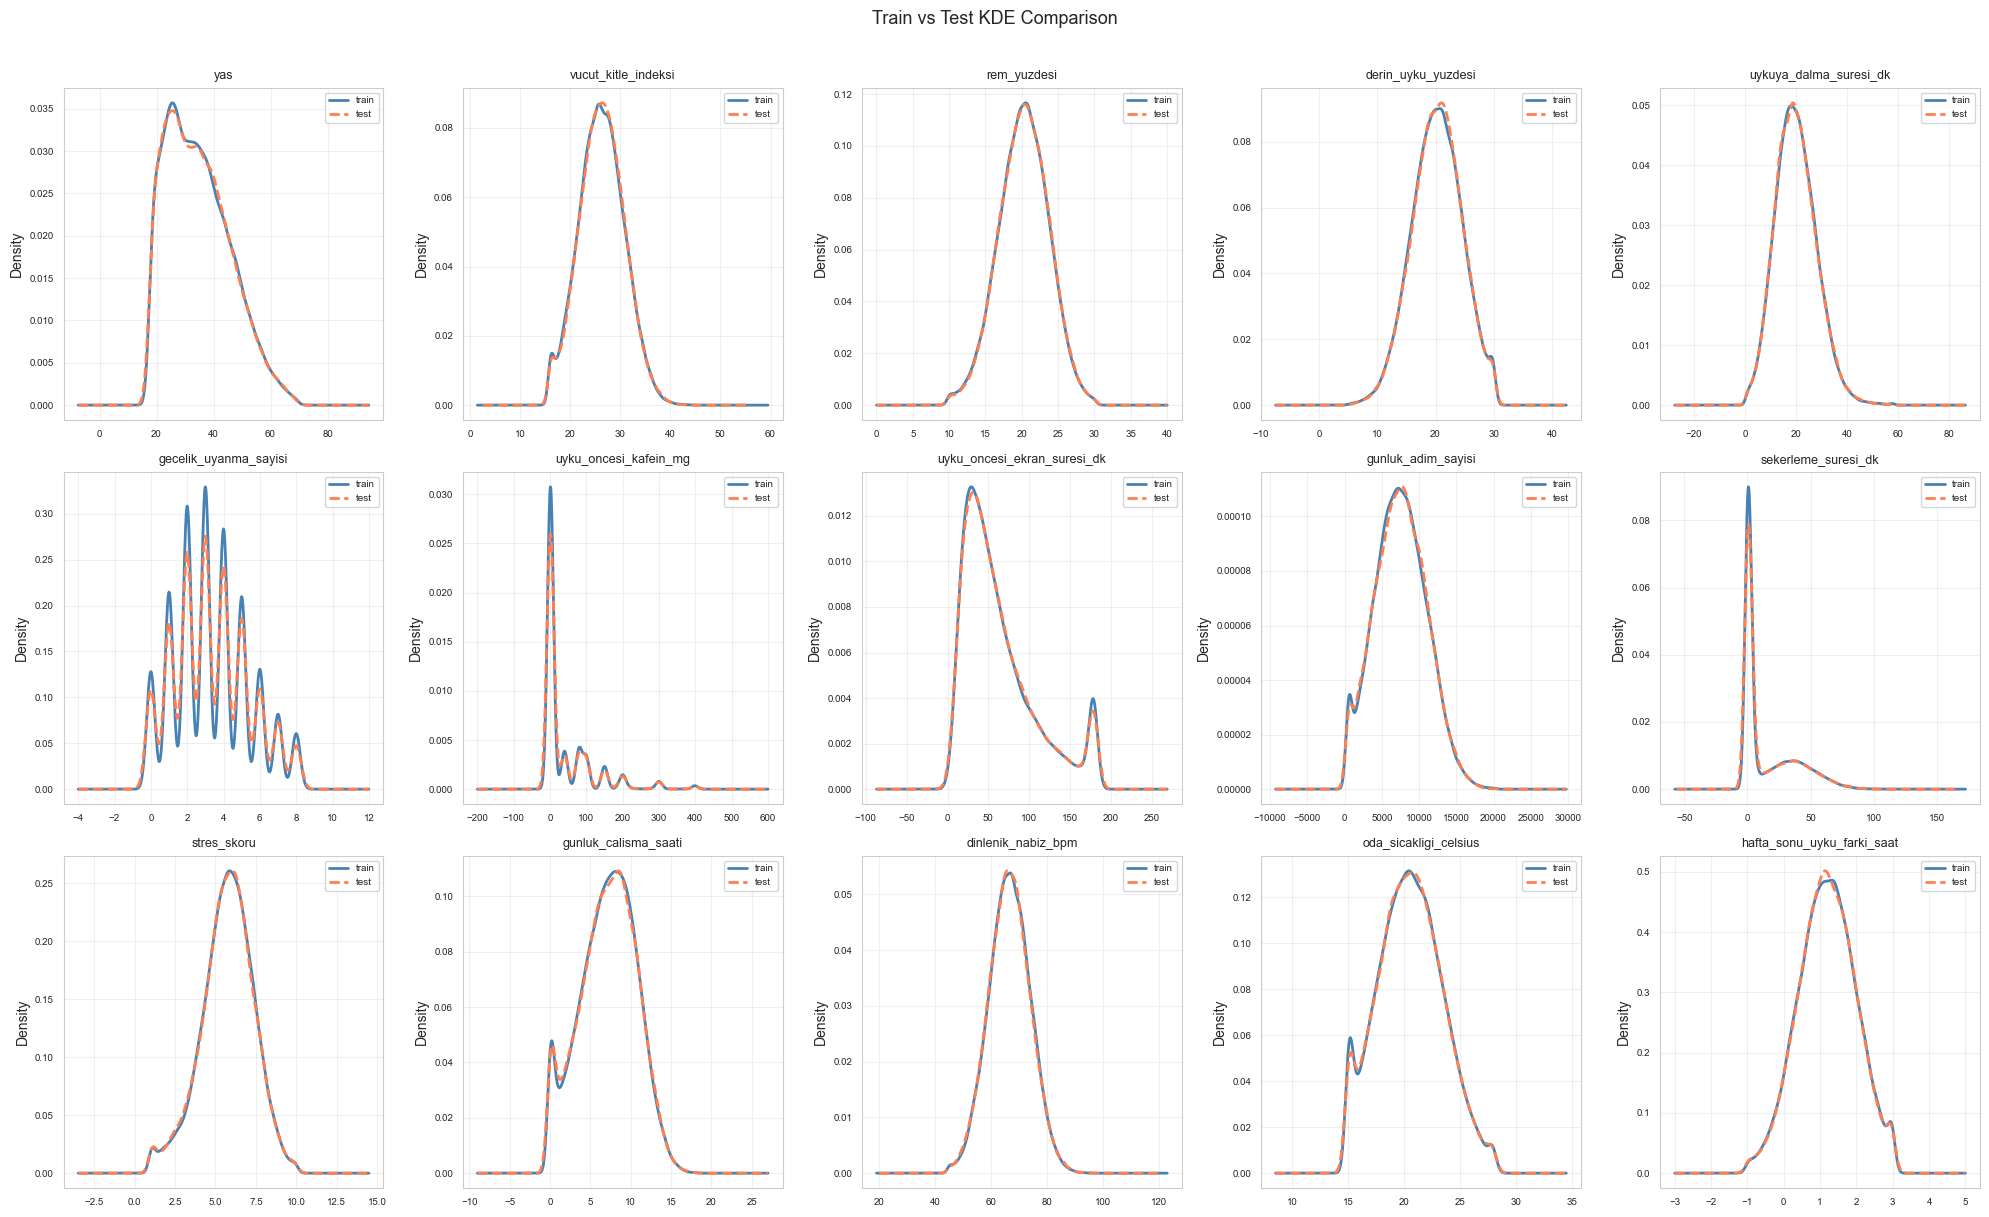

In [15]:
test_df = pd.read_csv('../data/test_x.csv')

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    train[col].dropna().plot.kde(ax=axes[i], label='train', color='steelblue', linewidth=2)
    test_df[col].dropna().plot.kde(ax=axes[i], label='test', color='coral', linewidth=2, linestyle='--')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(alpha=0.3)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j] )

plt.suptitle('Train vs Test KDE Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show() 

## Train vs Test KDE Bulguları

- Tüm sayısal feature'larda train (mavi) ve test (kırmızı) dağılımları neredeyse özdeş.
- **Data leakage riski yok**, test seti train ile aynı popülasyondan geliyor.
- Model train'de öğrendiklerini test'e güvenle genelleyebilir.

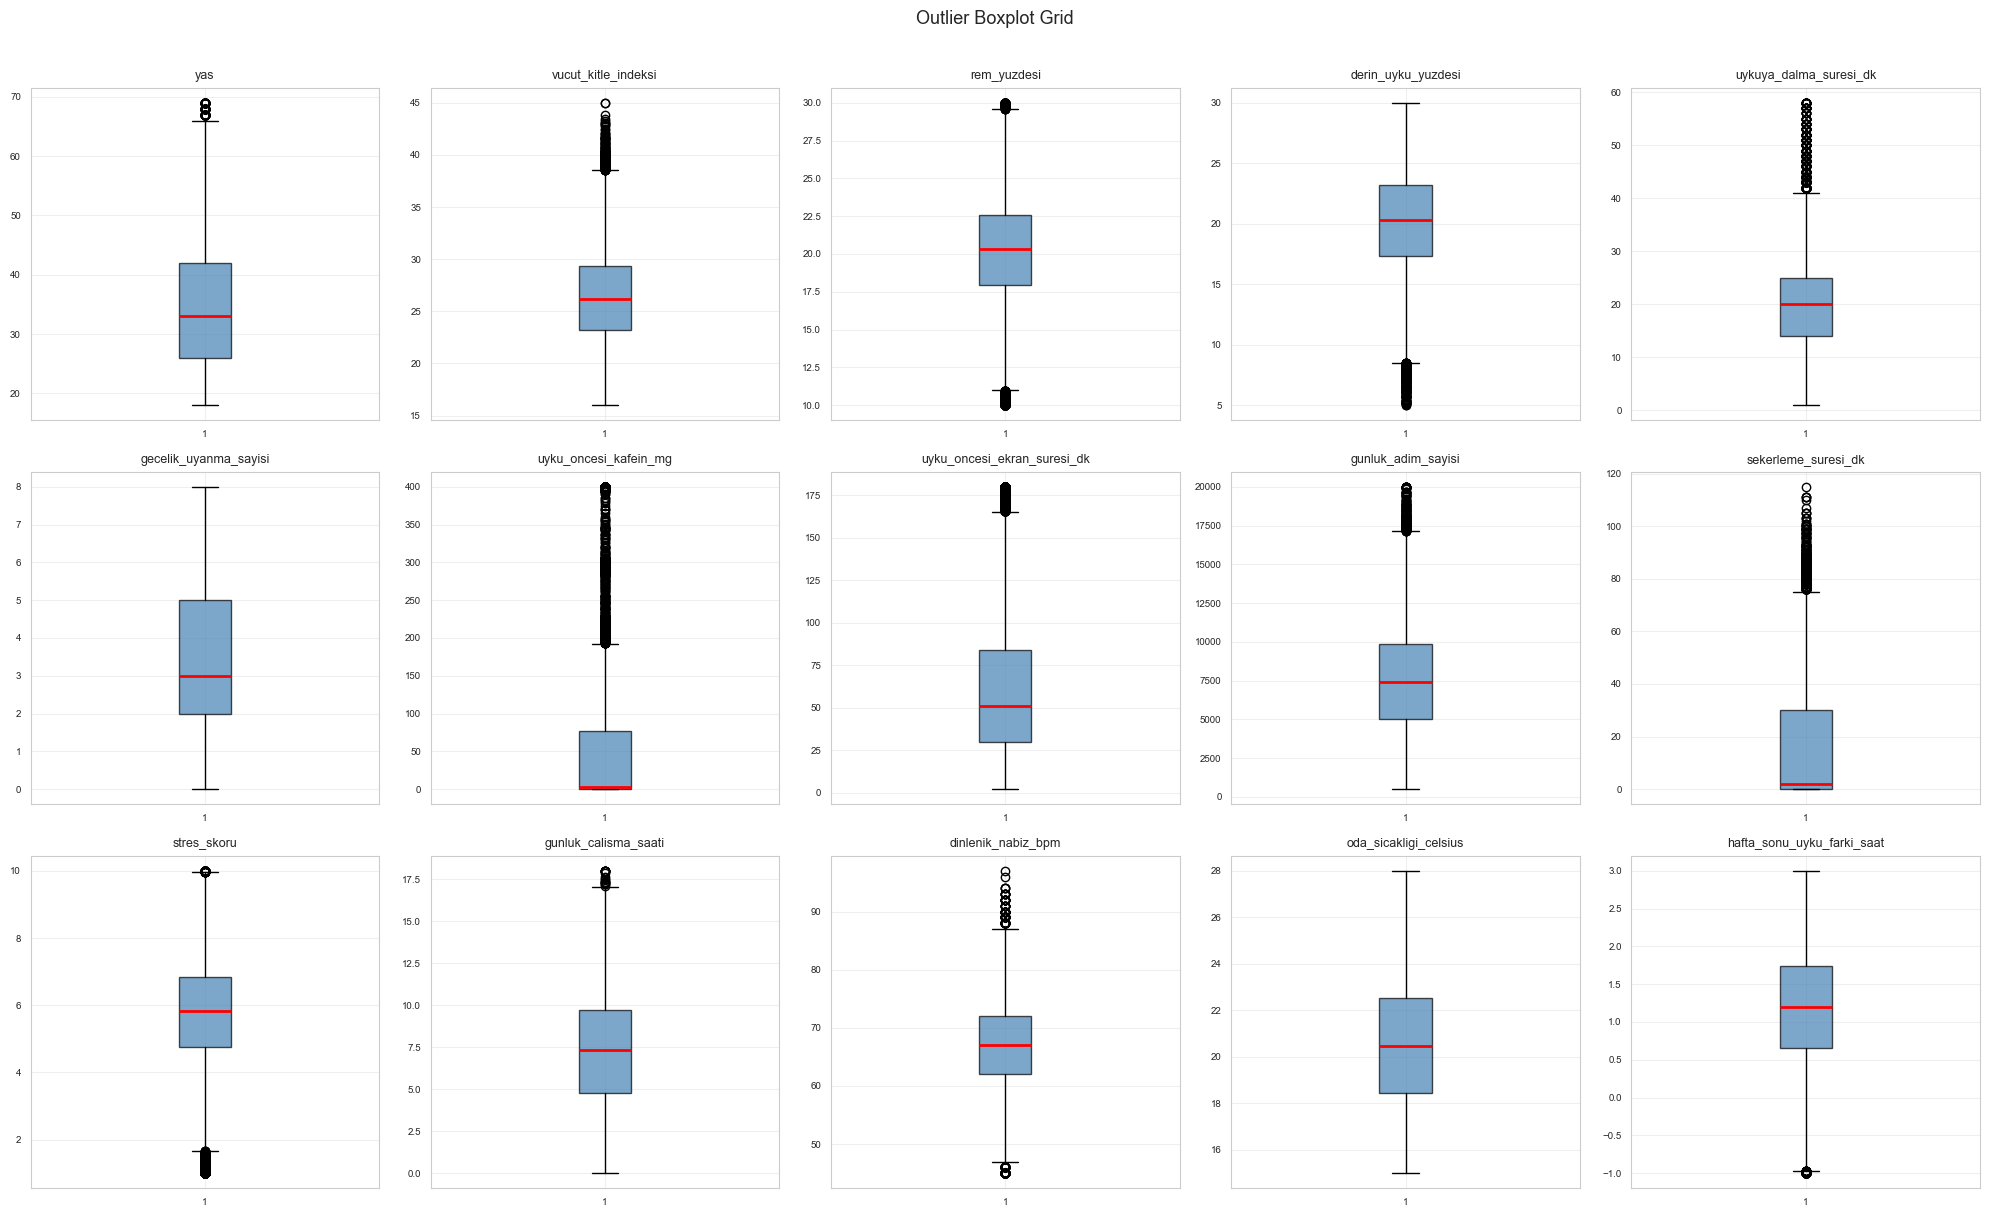

In [16]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(train[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(alpha=0.3)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Boxplot Grid', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Outlier Bulguları

- **uyku_oncesi_kafein_mg**: Belirgin üst outlier'lar (max 400mg) — gerçek veri, drop edilmez.
- **sekerleme_suresi_dk**: Uzun kuyruk, yüksek değerler mevcut — önceki analizle tutarlı.
- **uykuya_dalma_suresi_dk**: Üst outlier'lar var, beklenen fizyolojik sınırlar içinde.
- **dinlenik_nabiz_bpm**: Alt outlier'lar (düşük nabız) — sporcu profili olabilir.
- **hafta_sonu_uyku_farki_saat**: Alt outlier negatif (-1) — önceden not edilmişti.
- Geri kalan feature'larda outlier yok veya ihmal edilebilir düzeyde.

**Modelleme notu:** Tree-based modeller outlier'lardan etkilenmez, özel işlem gerekmez.

# EDA Özet — Grup 27

## Veri Seti
- Train: 56,000 satır × 24 kolon | Test: 24,000 satır × 23 kolon
- Target: `bilissel_performans_skoru` — sürekli, 0-10 arası, simetrik dağılım

## Kritik Bulgular

### Target
- Mean 5.91, Std 2.23 → log transform gerekmez
- 0'da ~450, 10'da ~1750 pile-up → clipping/ceiling effect

### En Güçlü Feature'lar (korelasyon)
| Feature | r | Yön |
|---|---|---|
| stres_skoru | -0.59 | güçlü negatif |
| rem_yuzdesi | +0.44 | güçlü pozitif |
| gunluk_calisma_saati | -0.34 | orta negatif |
| derin_uyku_yuzdesi | +0.28 | orta pozitif |
| gecelik_uyanma_sayisi | -0.27 | orta negatif |

### Eksik Değerler
- 6 kolonda %2-3.5 arası, bağımsız (MAR/MCAR) → Buse pipeline'da dolduracak

### Kategorik
- `ulke` (15), `meslek` (11) yüksek kardinalite → target encoding (Buse)
- `cinsiyet`, `gun_tipi`, `mevsim` düşük kardinalite → label encoding yeterli

### Train vs Test
- Tüm feature dağılımları özdeş → data leakage yok

## Feature Engineering Öncelikleri (features.py)
1. `add_stress_workload` — stres × çalışma (r = -0.59 × -0.34)
2. `add_sleep_efficiency` — REM + derin uyku
3. `add_sleep_debt` — 8 saatten eksik uyku
4. `add_caffeine_screen_interaction` — kafein × ekran
5. `add_bmi_category` — WHO kategorisi
6. `add_age_bins` — yaş grupları
7. `add_weekend_recovery` — hafta sonu pozitif fark